In [1]:
import numpy as np


m1 =1
m2 = 1
k1 = 1e04
k2 = 1

M = np.array([[m1, 0], [0, m2]])
K = np.array([[k1 + k2, -k2],[-k2, k2 ]])

print(K[0,0])
def naturalfrequencies(K, M):
    lmb1, lmb2 = np.linalg.eigvals(K @ M)
    w1 = np.sqrt(lmb1)
    w2 = np.sqrt(lmb2)
    return w1, w2

w1, w2 = naturalfrequencies(K, M)

T1 = 2 * np.pi/ w1
T2 = 2 * np.pi / w2 #correct Period to use

dt1 = T1/20
dt2 = T2 / 20

timeI1 = np.arange(0, 5*T1, dt1)
timeI2 = np.arange(0, 5*T2, dt2)

num_timesteps = len(timeI1)

print(w1, w2)

print(np.diag(np.diag(K)))  

print(M +  K, '\n')
print(M + np.diag(K), '\n')
print(M+np.diag(np.diag(K)), '\n')
print(K * np.eye(2))
print('\n',np.triu(np.tril(K)))

10001.0
100.00500037498125 0.9999499987504376
[[1.0001e+04 0.0000e+00]
 [0.0000e+00 1.0000e+00]]
[[ 1.0002e+04 -1.0000e+00]
 [-1.0000e+00  2.0000e+00]] 

[[1.0002e+04 1.0000e+00]
 [1.0001e+04 2.0000e+00]] 

[[1.0002e+04 0.0000e+00]
 [0.0000e+00 2.0000e+00]] 

[[ 1.0001e+04 -0.0000e+00]
 [-0.0000e+00  1.0000e+00]]

 [[1.0001e+04 0.0000e+00]
 [0.0000e+00 1.0000e+00]]


In [12]:
beta =0.3025 #0.3025#1/4
gamma = 0.6 #0.6#1/2
dt = dt2
method = ['trapezoidal', 'damped newmark']

d = []
v = []
a = []
ifin = []

d0 = np.array([10, 11])
v0 = np.array([0,0])
a0 = - np.linalg.solve(M, K@d0)
#print(a0)
d.append(d0)
v.append(v0)
a.append(a0)

dn = d0
vn = v0
an = a0

#d_tilde = dn + dt * vn + (dt**2/2) * (1 - 2*beta)*an
#v_tilde = vn + (1 - gamma)*dt*an
#a_tilde = np.zeros(2)

Mstar = M + dt**2 * beta *np.diag(np.diag( K) )

#dF0 = - M @ a_tilde - K @ d_tilde
#dFi = dF0
#print(Mstar)
#print(dF0)

for t in range(num_timesteps-1):
   
    #print(t)
    #print(dn)
    
    d_tilde = dn + dt * vn + (dt**2/2) * (1 - 2*beta)*an
    v_tilde = vn + (1 - gamma)*dt*an
    a_tilde = np.zeros(2)
    
    dF0 = - M @ a_tilde - K @ d_tilde
    dFi = dF0
    #print(d_tilde)
    
    #predictor
    i=0
    di = d_tilde
    vi = v_tilde
    ai = a_tilde

    #loop
    while i < 4:
        i+=1     
        da = np.linalg.solve(Mstar, dFi)
        #print(da)
        #corrector
        ai = ai + da
        vi = vi + gamma * dt * da
        di = di + beta * dt**2 * da

        dFi = - M @ ai - K @ di

        if np.linalg.norm(dFi) < 1e-4 * np.linalg.norm(dF0):
            an = ai
            vn = vi
            dn = di
            ifin.append(i)
            break
    d.append(dn)
    v.append(vn)
    a.append(an)
#print(d)   

d = np.array(d)
v = np.array(v)
a = np.array(a)

print(ifin)


[1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


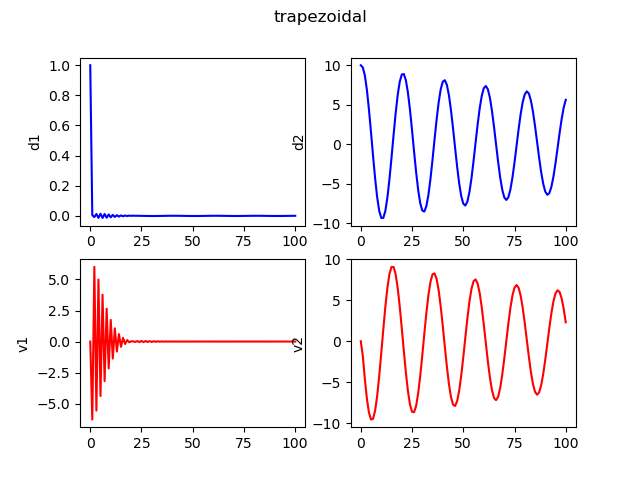

In [11]:
import matplotlib.pyplot as plt
%matplotlib widget

d1 = d[:, 0]
d2 = d[:, 1]
v1 = v[:,0]
v2 = v[:, 1]

fig, ax = plt.subplots(2,2)

ax[0,0].plot(range(num_timesteps), d1, label = 'd1', color = 'b')
ax[0,0].set_ylabel( 'd1')

ax[1,0].plot( range(num_timesteps), v1, label = 'v1', color = 'r')
ax[1,0].set_ylabel( 'v1')

ax[0,1].plot( range(num_timesteps), d2, label = 'd2', color = 'b')
ax[0,1].set_ylabel( 'd2')

ax[1,1].plot( range(num_timesteps), v2, label = 'v2', color = 'r')
ax[1,1].set_ylabel( 'v2')

plt.suptitle(f'{method[0]}')
plt.show()

In [3]:
J = np.zeros_like(K.tolist())

J[0,0] = 50.0

print(J)

[[50.  0.]
 [ 0.  0.]]


In [4]:
g0 = np.array([1, 10])
print(g0.reshape(-1, 1))

[[ 1]
 [10]]


In [5]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

def predictor_multi_corrector_newmark(
M, M_mod, C, K, F, d0, v0, a0, delta_t,
num_steps,
beta, gamma, tol=1e-4, max_iter=15
):
    """
    Predictor Multi-Corrector Newmark Algorithm.
    Parameters:
    M (ndarray): Mass matrix.
    C (ndarray): Damping matrix.
    K (ndarray): Stiffness matrix.
    F (ndarray): Force vector at each time step.
    d0 (ndarray): Initial displacement vector.
    v0 (ndarray): Initial velocity vector.
    a0 (ndarray): Initial acceleration vector.
    delta_t (float): Time step size.
    beta (float): Newmark parameter beta.
    gamma (float): Newmark parameter gamma.
    tol (float): Convergence tolerance for corrector iterations.
    max_iter (int): Maximum iterations for corrector.
    Returns:
    d (ndarray): Displacement matrix [n_dof].
    v (ndarray): Velocity matrix [n_dof].
    a (ndarray): Acceleration matrix [n_dof].
    """
    d_list, v_list, a_list = [], [], []
    d_i, v_i, a_i = d0.copy(), v0.copy(), a0.copy()
    d_list.append(d_i.copy())
    v_list.append(v_i.copy())
    a_list.append(a_i.copy())
    for n in range(1, num_steps+1):
        has_converged, num_converge = False, -1
        # Predictor step
        d_i += delta_t * v_i + (0.5 * delta_t**2) * (1 - 2*beta) * a_i
        v_i += delta_t * (1 - gamma) * a_i
        a_i = np.zeros(d_i.shape)
        delta_F = F - M @ a_i - C @ v_i - K @ d_i
        delta_F0_norm = np.linalg.norm(delta_F)
        for i in range(max_iter):
            # Compute delta_F
            delta_F = F - M @ a_i - C @ v_i - K @ d_i
            # Corrector step
            delta_a = np.linalg.solve(M_mod, delta_F)
            a_i += delta_a
            v_i += gamma * delta_t * delta_a
            d_i += beta * (delta_t ** 2) * delta_a
            # Check convergence
            if np.linalg.norm(delta_F) <= tol * delta_F0_norm:
                has_converged = True
                num_converge = i
                break
            if not has_converged:
                print(f"Warning! Did not converge on step {n}")
            else:
                print(f"Step {n} converged in {num_converge} steps")
        d_list.append(d_i.copy())
        v_list.append(v_i.copy())
        a_list.append(a_i.copy())
    return d_list, v_list, a_list

In [ ]:
import pandas as pd
class Newmark:
    """
    Newmark method
    """
    def __init__(self):
        # task number
        self.number_task = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        # default degree
        self.degree = 4
        # four degree of freedom default matrix
        mass = 1.0
        k = 1.0
        c = 0.0
        self.m_matrix = np.array([[mass, 0, 0, 0], [0, mass, 0, 0], [0, 0, mass,
                                                                     0], [0, 0, 0, mass]])
        self.k_matrix = np.array([[k, -k, 0, 0], [-k, 2 * k, -k, 0], [0, -k, 2 *
                                                                      k, -k], [0, 0, -k, 2 * k]])
        self.c_matrix = np.array([[c, -c, 0, 0], [-c, 2 * c, -c, 0], [0, -c, 2 *
                                                                      c, -c], [0, 0, -c, 2 * c]])
        # initial condition
        self.u0 = np.zeros([self.degree, 1])
        self.v0 = np.zeros([self.degree, 1])
        # time step
        self.t_total = 10.0
        self.dt = 0.001
        self.t_list = np.arange(0.0, self.t_total + self.dt, self.dt).reshape(-1,
                                                                              1)
        # parameters in new-mark method
        self.gamma = 1 / 2
        self.beta = 1 / 4

        # result
        self.u_all = np.array([])
        self.v_all = np.array([])
        self.a_all = np.array([])
        self.f_all_pred = np.array([])

    def input_degree(self, degree):
        """
        define degree
        :param degree: 自由度
        :return:
        """
        self.degree = degree
    def input_m_matrix(self, m_matrix):
        """
        define mass matrix
        :param m_matrix:
        :return:
        """
        m_matrix = np.array(m_matrix)
        if m_matrix.shape == (self.degree, self.degree):
            self.m_matrix = m_matrix
        else:
            print("The shape of the mass matrix is inconsistent with the degrees of freedom！")

    def input_k_matrix(self, k_matrix):
        """
        define stiffness matrix
        :param k_matrix:
        :return:
        """
        k_matrix = np.array(k_matrix)
        if k_matrix.shape == (self.degree, self.degree):
            self.k_matrix = k_matrix
        else:
            print("The shape of the stiffness matrix is inconsistent with the degrees of freedom！")

    def input_c_matrix(self, c_matrix):
        """
        define damping matrix
        :param c_matrix:
        :return:
        """
        c_matrix = np.array(c_matrix)
        if c_matrix.shape == (self.degree, self.degree):
            self.c_matrix = c_matrix
        else:
            print("The shape of the damping matrix is inconsistent with the degrees of freedom！")

    def input_initial_u(self, u0):
        """
        define initial displacement
        :param u0:
        :return:
        """
        u0 = np.array(u0).reshape(-1, 1)
        if u0.shape[0] == self.degree:
            self.u0 = u0
        else:
            print("The shape of the u0 is inconsistent with the degrees of freedom！")
            
    def input_initial_v(self, v0):
        """
        define initial velocity
        :param v0:
        :return:
        """
        v0 = np.array(v0).reshape(-1, 1)
        if v0.shape[0] == self.degree:
            self.v0 = v0
        else:
            print("The shape of the v0 is inconsistent with the degrees of freedom！")

    def set_calculate_time(self, t_total, dt):
        """
        define the total time to calculate and beta time of each step
        :param t_total:
        :param dt:
        :return:
        """
        self.t_total = t_total
        self.dt = dt
        self.t_list = np.arange(0.0, self.t_total + self.dt, self.dt).reshape(-1, 1)

    def set_newmark_parameters(self, gamma, beta):
        """
        parameters in the newmark method
        (1/2,1/4-Trapezoidal method); (1/2, 1/6- Linear acceleration method);
        (1/2, 0 - Central difference method)
        :param gamma:
        :param beta:
        :return:
        """
        self.gamma = gamma
        self.beta = beta



0.003333333333333333

In [3]:
h = np.array([[1,2,3], [15,16,17]])
hl = h[0,:]
print(hl, hl[np.newaxis, :])

[1 2 3] [[1 2 3]]
